In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
import cv2
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
import lightgbm as lgb
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [ ]:

DATASET_PATH = "/kaggle/input/shapdataset/shapdataset"
IMG_SIZE = 128

data = []
labels = []
class_names = []

for shape in os.listdir(DATASET_PATH):
    shape_path = os.path.join(DATASET_PATH, shape)

    for quality in os.listdir(shape_path):
        quality_path = os.path.join(shape_path, quality)
        class_label = f"{shape}_{quality}"
        if class_label not in class_names:
            class_names.append(class_label)
        label_index = class_names.index(class_label)

        for img_name in os.listdir(quality_path):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img_path = os.path.join(quality_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img)
            labels.append(label_index)

data = np.array(data) / 255.0
labels_cat = to_categorical(labels, num_classes=len(class_names))


In [ ]:

X_temp, X_test, y_temp, y_test = train_test_split(
    data,
    labels_cat,
    test_size=0.10,
    random_state=42,
    stratify=labels_cat
)


X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1111,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (7872, 128, 128, 3)
Validation: (984, 128, 128, 3)
Test: (985, 128, 128, 3)


In [ ]:

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

counts = Counter(np.argmax(y_train, axis=1))
max_count = max(counts.values())

X_train_aug = []
y_train_aug = []

for class_idx, count in counts.items():
    X_class = X_train[np.argmax(y_train, axis=1) == class_idx]
    y_class = y_train[np.argmax(y_train, axis=1) == class_idx]

    num_to_augment = max_count - count
    if num_to_augment > 0:
        i = 0
        for X_batch, y_batch in datagen.flow(X_class, y_class, batch_size=1):
            X_train_aug.append(X_batch[0])
            y_train_aug.append(y_batch[0])
            i += 1
            if i >= num_to_augment:
                break
    X_train_aug.extend(X_class)
    y_train_aug.extend(y_class)

X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

print(" Data Augmentation:")
for idx in range(len(class_names)):
    print(f"{class_names[idx]}: {(y_train_aug.argmax(axis=1) == idx).sum()}")


 Data Augmentation:
Triangle_Meduim: 1245
Triangle_Bad: 1245
Triangle_perfect: 1245
circle_circle_irregular_truue: 1245
circle_circle_medium: 1245
circle_circleperfct: 1245
Rectangle_Good: 1245
Rectangle_Meduim: 1245
Rectangle_Bad: 1245


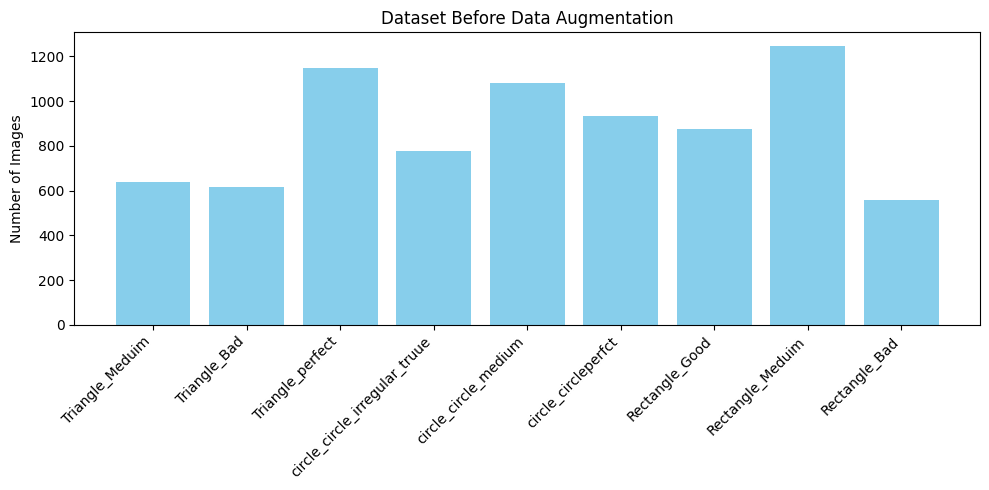

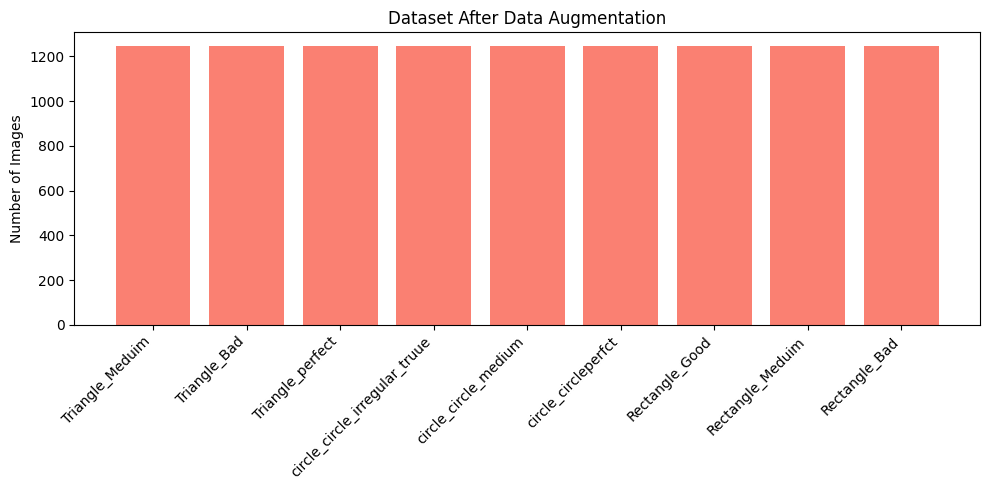

In [ ]:
counts_before = Counter(np.argmax(y_train, axis=1))
classes = class_names
counts_before_list = [counts_before[i] for i in range(len(classes))]


plt.figure(figsize=(10,5))
plt.bar(classes, counts_before_list, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Images")
plt.title("Dataset Before Data Augmentation")
plt.tight_layout()
plt.show()

counts_after = Counter(np.argmax(y_train_aug, axis=1))
counts_after_list = [counts_after[i] for i in range(len(classes))]


plt.figure(figsize=(10,5))
plt.bar(classes, counts_after_list, color='salmon')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Images")
plt.title("Dataset After Data Augmentation")
plt.tight_layout()
plt.show()


In [ ]:

input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.2)(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.3)(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.4)(x)

x = GlobalAveragePooling2D()(x)
dense = Dense(256, activation='relu')(x)
output = Dense(9, activation='softmax')(dense)

cnn_model = Model(inputs=input_layer, outputs=output)
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cnn_model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16
)

I0000 00:00:1768316024.918438      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768316024.922365      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/20


I0000 00:00:1768316034.245746     123 service.cc:152] XLA service 0x7ab7a4025d80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768316034.245796     123 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768316034.245803     123 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768316034.759886     123 cuda_dnn.cc:529] Loaded cuDNN version 91002


 10/701 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.0663 - loss: 2.4546  

I0000 00:00:1768316040.189399     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


697/701 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3553 - loss: 1.7430

2026-01-13 14:54:09.617893: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-13 14:54:09.759971: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


701/701 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - accuracy: 0.3561 - loss: 1.7408 - val_accuracy: 0.1077 - val_loss: 7.4870
Epoch 2/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6246 - loss: 1.0305 - val_accuracy: 0.1331 - val_loss: 10.0202
Epoch 3/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7156 - loss: 0.7586 - val_accuracy: 0.4126 - val_loss: 1.9015
Epoch 4/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7738 - loss: 0.6046 - val_accuracy: 0.6728 - val_loss: 0.9208
Epoch 5/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7992 - loss: 0.5470 - val_accuracy: 0.2683 - val_loss: 4.9147
Epoch 6/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8218 - loss: 0.4773 - val_accuracy: 0.6402 - val_loss: 1.0606
Epoch 7/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8253 - loss: 0.4597 - val_accuracy: 0.7744 - val_loss: 0.7123
Epoch 8/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8519 - loss: 0.3978 - val_accuracy: 0.6

In [ ]:

feature_extractor = Model(inputs=cnn_model.input, outputs=cnn_model.layers[-2].output)

X_train_features = feature_extractor.predict(X_train_aug, batch_size=16)
X_val_features   = feature_extractor.predict(X_val, batch_size=16)
X_test_features  = feature_extractor.predict(X_test, batch_size=16)


701/701 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [ ]:
feature_extractor.save("feature_extractor.h5")


In [ ]:

y_train_lgbm = y_train_aug.argmax(axis=1)
y_val_lgbm   = y_val.argmax(axis=1)
y_test_lgbm  = y_test.argmax(axis=1)


lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(class_names),
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)


lgbm.fit(X_train_features, y_train_lgbm)


y_pred_lgbm = lgbm.predict(X_test_features)


/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013090 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 63312
[LightGBM] [Info] Number of data points in the train set: 11205, number of used features: 255
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Info] Start training from score -2.197225
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import joblib
joblib.dump(lgbm, "lgbm_model.pkl", compress=3)
print("LightGBM model has been saved successfully!")


LightGBM model has been saved successfully!


In [ ]:
print("LightGBM Accuracy:",
      accuracy_score(y_test_lgbm, y_pred_lgbm))

print(classification_report(
    y_test_lgbm,
    y_pred_lgbm,
    target_names=class_names
))


LightGBM Accuracy: 0.9644670050761421
                               precision    recall  f1-score   support

              Triangle_Meduim       0.89      0.96      0.92        80
                 Triangle_Bad       0.95      0.91      0.93        77
             Triangle_perfect       0.99      0.97      0.98       144
circle_circle_irregular_truue       0.99      0.98      0.98        97
         circle_circle_medium       0.96      0.96      0.96       135
          circle_circleperfct       0.97      0.98      0.97       117
               Rectangle_Good       0.95      0.97      0.96       109
             Rectangle_Meduim       0.98      0.97      0.97       156
                Rectangle_Bad       0.99      0.94      0.96        70

                     accuracy                           0.96       985
                    macro avg       0.96      0.96      0.96       985
                 weighted avg       0.97      0.96      0.96       985



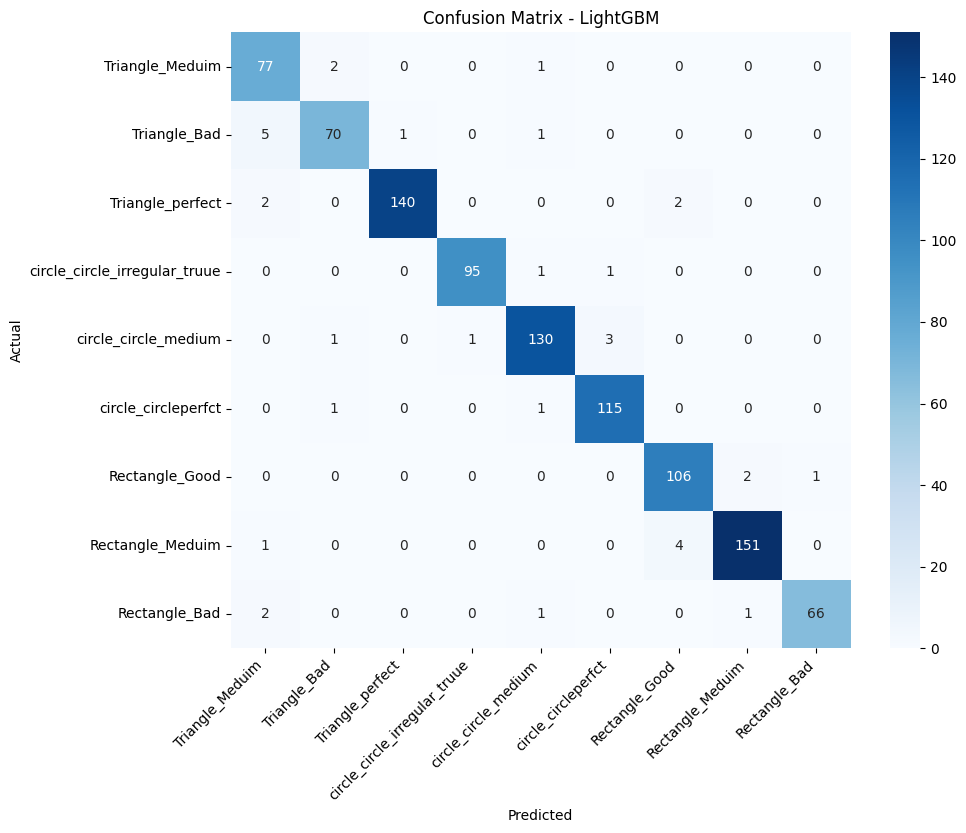

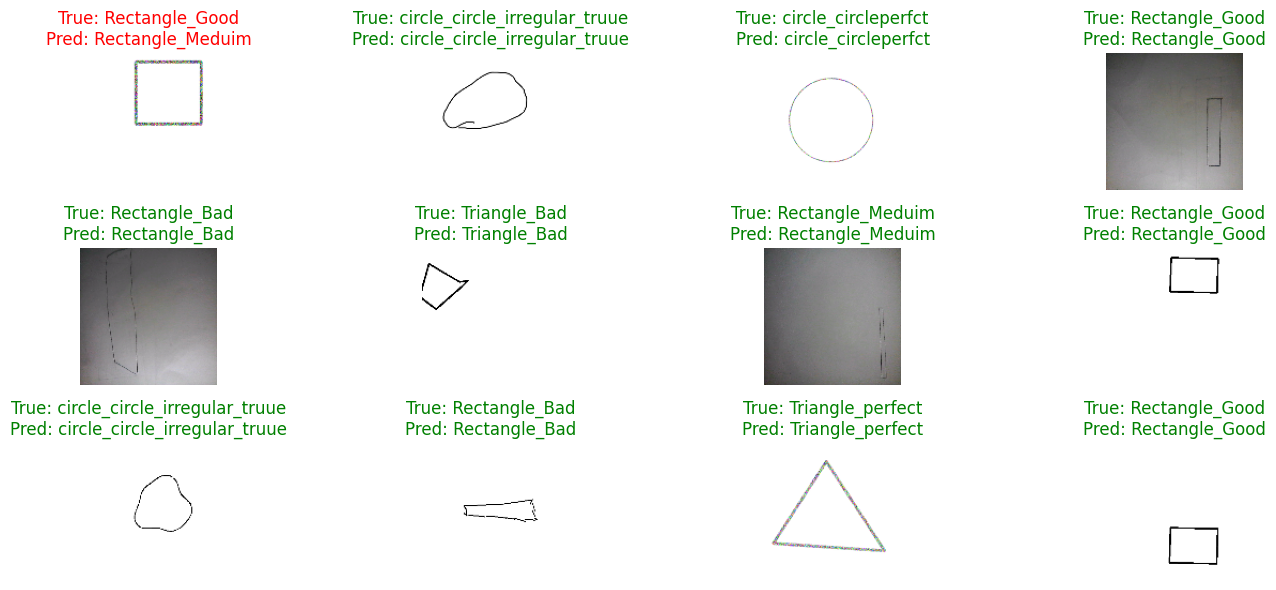

In [ ]:


cm_lgbm = confusion_matrix(y_test_lgbm, y_pred_lgbm)

plt.figure(figsize=(10,8))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


num_samples = 12
indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(15,6))
for i, idx in enumerate(indices):
    plt.subplot(3, 4, i+1)
    plt.imshow(X_test[idx])
    plt.axis('off')
    true_label = class_names[y_test_lgbm[idx]]
    pred_label = class_names[y_pred_lgbm[idx]]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
plt.tight_layout()
plt.show()


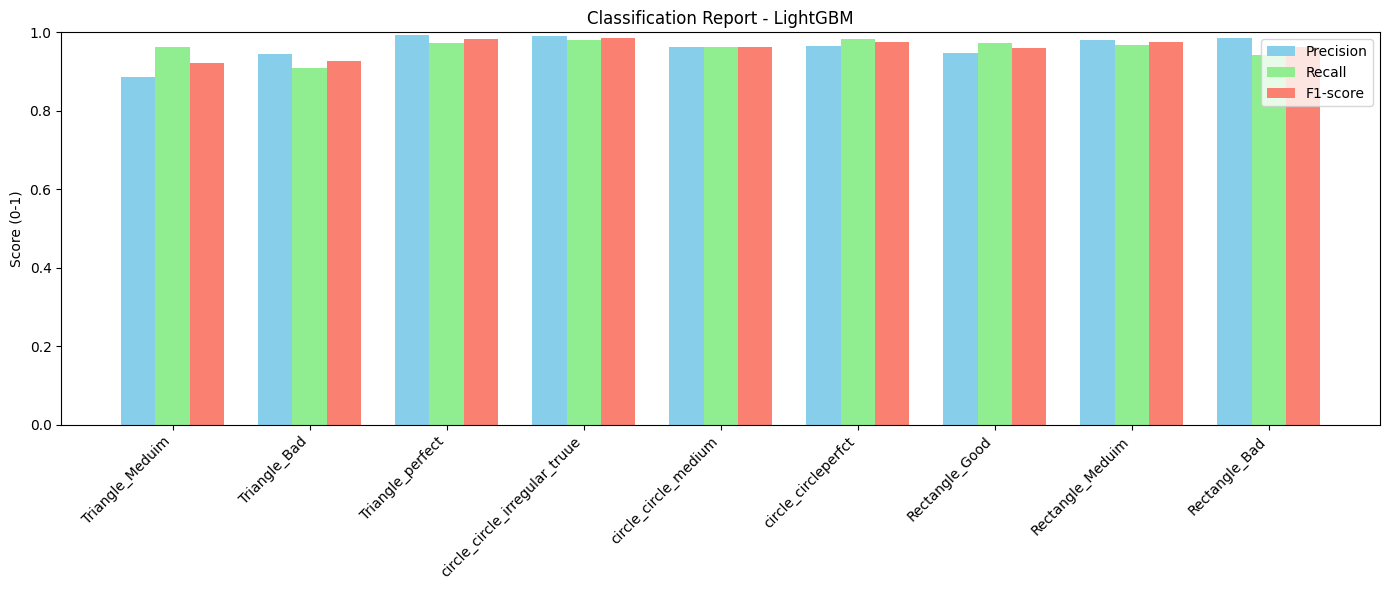

In [ ]:

report_lgbm = classification_report(
    y_test_lgbm,
    y_pred_lgbm,
    target_names=class_names,
    output_dict=True
)

precision = [report_lgbm[c]['precision'] for c in class_names]
recall    = [report_lgbm[c]['recall'] for c in class_names]
f1        = [report_lgbm[c]['f1-score'] for c in class_names]

x = np.arange(len(class_names))
width = 0.25


plt.figure(figsize=(14,6))

plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

plt.xticks(x, class_names, rotation=45, ha='right')
plt.ylabel('Score (0-1)')
plt.title('Classification Report - LightGBM')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


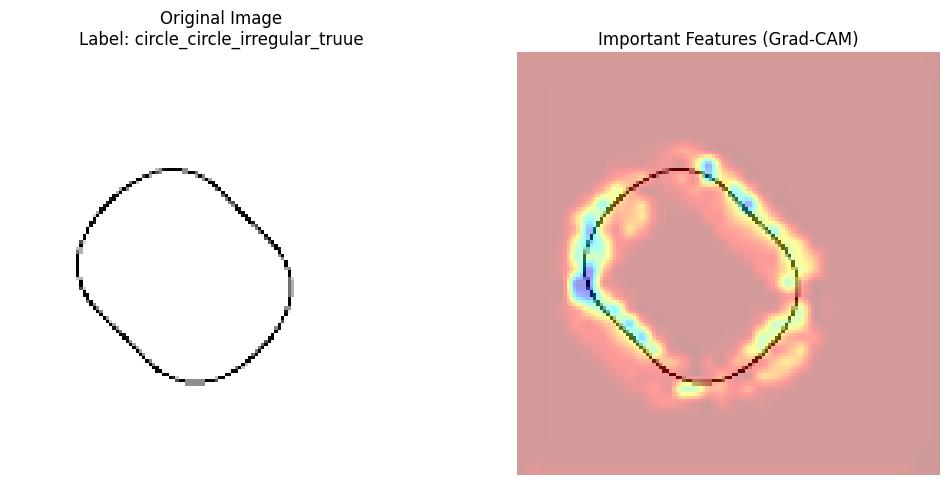

In [ ]:



idx = random.randint(0, len(X_test)-1)
img = X_test[idx]

label_idx = y_test_lgbm[idx]
label_name = class_names[label_idx]


def preprocess_img(img):
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)
    elif img.shape[-1] == 1:
        img = np.concatenate([img]*3, axis=-1)
    return (img*255).astype(np.uint8)

img_proc = preprocess_img(img)
input_img = np.expand_dims(img_proc/255.0, axis=0)


last_conv_layer = cnn_model.get_layer("conv2d_2")

grad_model = tf.keras.models.Model(
    [cnn_model.inputs],
    [last_conv_layer.output, cnn_model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(input_img)
    pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]

grads = tape.gradient(class_channel, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)[0]
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)


heatmap = cv2.resize(heatmap, (img_proc.shape[1], img_proc.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img_proc, 0.6, heatmap_color, 0.4, 0)

plt.figure(figsize=(12,6))


plt.subplot(1,2,1)
plt.imshow(img_proc)
plt.title(f"Original Image\nLabel: {label_name}")
plt.axis('off')


plt.subplot(1,2,2)
plt.imshow(superimposed_img)
plt.title("Important Features (Grad-CAM)")
plt.axis('off')

plt.show()
